# WORK 1 : WAVEFORM DETECTION IN WHITE GAUSSIAN NOISE

### Objective

Evaluate the performance of a Gaussian likelihood for detecting a toy inspiral chirp signal in simulated white Gaussian noise.

### Procedure

1. Generate a toy inspiral chirp waveform.
2. Inject the waveform into simulated white Gaussian noise.
3. Compute the Gaussian log-likelihood for
   - Signal + noise
   - Noise only
4. Repeat the experiment using Monte Carlo simulations.
5. Calculate the Probability of Detection (PD) and False Alarm Probability (FAP).
6. Construct the Receiver Operating Characteristic (ROC) curve.

### Outputs

- Simulated detector data with the injected chirp signal.
- ROC curve showing the detection performance.

1.0


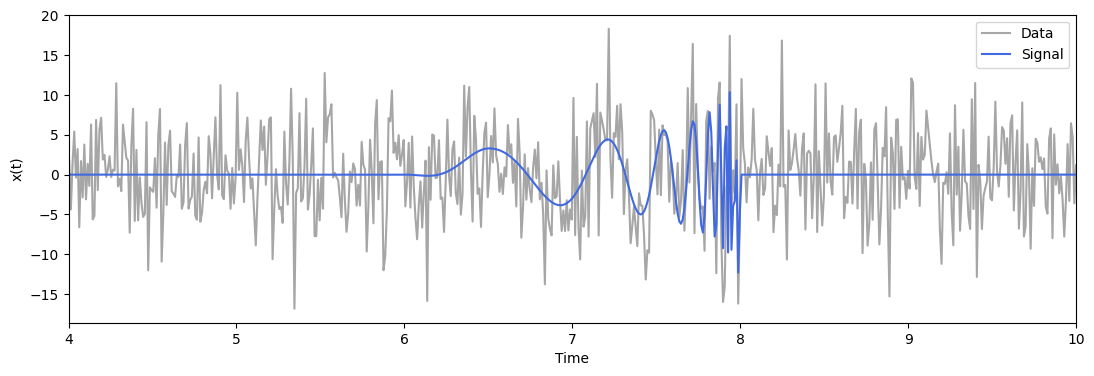

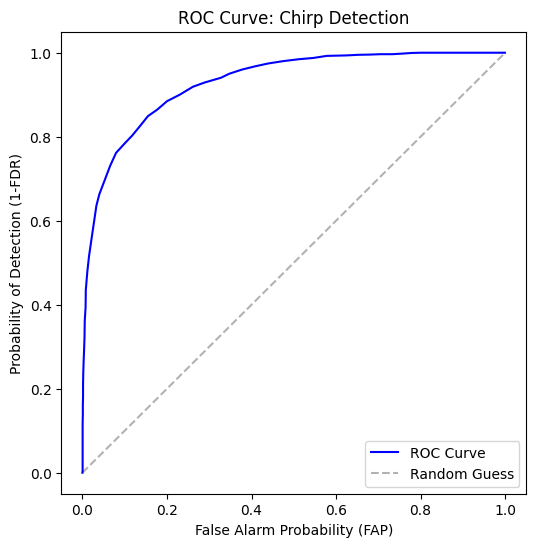

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal.windows import tukey

# -----------------------------
#  2-parameter toy chirp model
# -----------------------------
def generate_chirp(t, A, chirp_rate, t_c):
    h = np.zeros_like(t)
    valid = (t < t_c) & (t > (t_c - 2.0))
    if not np.any(valid):
        return h
    tau = t_c - t[valid]
    phase = -2.0 * chirp_rate * (tau + 1e-5)**(-0.25)
    amplitude = A * np.sqrt(chirp_rate / (tau + 0.1))
    signal = amplitude * np.sin(phase)
    # Tukey window only at the beginning
    window = tukey(len(signal), alpha=0.5)
    taper = np.ones_like(signal)
    half = len(window) // 2
    taper[:half] = window[:half]
    signal *= taper
    h[valid] = signal
    return h
    
def log_likelihood(params, t, data, sigma):
    A0, cr, tc = params
    model = generate_chirp(t, A0 , cr, tc)
    residual = data - model
    return -0.5 * len(data) * np.log(2.0 * np.pi * sigma**2) - 0.5 * np.sum(residual**2 *dt / sigma**2)

# -----------------------------
# 2. Parameters & Setup
# -----------------------------

N = 1000
t = np.linspace(0, 10, N)
cr_true, t_c_true = 20.0, 8.0
params = (1,cr_true, t_c_true)
dt = t[1]-t[0]
sigma_noise = 5

# Calibrate noise for SNR 10-15 dB
signal_template = generate_chirp(t, *params)
snr = np.sqrt(np.sum(signal_template**2/ sigma_noise**2)*dt)
A0 = 1 / snr
params = (A0,cr_true, t_c_true)
signal_template =  generate_chirp(t, *params)
print(np.sqrt(np.sum(signal_template**2/ sigma_noise**2)*dt))

# Test Plot
noise = np.random.normal(0, sigma_noise, N)
plt.figure(figsize=(13,4))
plt.plot(t, noise+signal_template , label= 'Data', color='grey', alpha=0.7)
plt.plot(t, signal_template, label='Signal', color='royalblue')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.xlim([4,10])
plt.legend()

num_trials = 2000
log_l_signal = []
log_l_noise = []

# -----------------------------
# 3. Monte Carlo Simulation
# -----------------------------

for _ in range(num_trials):
    noise = np.random.normal(0, sigma_noise, N)
    
    # H1: Data contains signal + noise
    data_signal = signal_template + noise
    # H0: Data contains noise only
    data_noise = noise
    
    log_l_signal.append(log_likelihood(params, t, data_signal, sigma_noise))
    log_l_noise.append(log_likelihood(params, t, data_noise, sigma_noise))

# -----------------------------
# 4. ROC Curve Generation
# -----------------------------

# The decision statistic is the Likelihood Ratio (or Log-Likelihood difference)
stats_signal = np.array(log_l_signal)
stats_noise = np.array(log_l_noise)

thresholds = np.linspace(min(stats_noise.min(), stats_signal.min()), 
                         max(stats_noise.max(), stats_signal.max()), 100)

PD = [np.sum(stats_signal > T) / num_trials for T in thresholds]
FAP = [np.sum(stats_noise > T) / num_trials for T in thresholds]

# -----------------------------
# 5. Plotting
# -----------------------------

plt.figure(figsize=(6,6))
plt.plot(FAP, PD, 'b-', label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Guess')
plt.xlabel("False Alarm Probability (FAP)")
plt.ylabel("Probability of Detection (1-FDR)")
plt.title("ROC Curve: Chirp Detection")
plt.legend()
plt.show()